# Cross-species divergence of best-predicted developmental splice sites

Goal: find splice sites that are **developmentally dynamic in human** and **well predicted by
the model**, but whose orthologous site has a **different developmental trajectory in one or
more other species** — most simply, *not* developmentally dynamic there.

These are the interesting cases: the model gets human right, and the biology genuinely diverges
across species, so the model's cross-species predictions can be scrutinised against a real
lineage-specific difference.

## Approach
1. **Orthology** — map human splice sites to their orthologues in other species
   (`splice_sites_all_species_from_human.tsv.gz`, as in the *Developmental dynamics* section of
   [splice_usage_data.ipynb](splice_usage_data.ipynb)).
2. **Human** — per site (in a focus tissue), measure developmental **amplitude** of true usage
   and how well the model predicts the trajectory (Pearson r, MAE). Keep dynamic + well-predicted.
3. **Other species** — at each orthologous site, measure the same true amplitude and the
   cross-species trajectory correlation with human.
4. **Divergence** — flag species where the site is *not* dynamic (or poorly correlated with the
   human trajectory); keep human sites divergent in ≥1 species; rank by human prediction quality.

## Setup

In [18]:
import os
import re
import json
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.interpolate import interp1d

from alphagenome_pytorch.plotting.splicing import (
    TISSUE_COLORS, TISSUE_ORDER, SPECIES_ORDER, SPECIES_SCI,
    classify_cluster_shape,
)

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})

In [19]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data"
USAGE_TMPL = os.path.join(DATA_DIR, "combined_usage_data_{species}.parquet")

MODEL      = "lora_32_human_mouse_rat_rabbit_opossum"
PRED_DIR   = os.path.join("/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai",
                          MODEL, "preds_intersect_protein_coding")

ORTHO_SITES = ("/home/elek/sds/sd17d003/Anamaria/folds_splits/"
               "results_splice_sites/splice_sites_all_species_from_human.tsv.gz")

FOCUS_TISSUE   = "Cerebellum"        # tissue to compare trajectories in (most dev-dynamic)
OTHER_SPECIES  = ["mouse", "rat", "rabbit", "opossum"]

# Developmental-dynamics / prediction thresholds
ORTHO_TOL      = 2      # bp: snap an orthologue to the nearest predicted site within +/- this
MIN_TIMEPOINTS = 5      # min observed (reads>0) timepoints to score a trajectory
AMP_DYNAMIC    = 0.40   # human amplitude (max-min SSE) >= this -> clearly "dynamic"
AMP_FLAT       = 0.10   # other-species amplitude <= this -> genuinely "flat"
MIN_AMP_GAP    = 0.30   # (human - other) amplitude gap required -> real divergence
R_WELL_PRED    = 0.70   # Pearson(true, pred) >= this -> "well predicted"
MAE_WELL_PRED  = 0.20   # RMSE(true, pred) <= this

# Shape vocabulary (also acts as the shape restriction — narrow these to be stricter,
# e.g. DYNAMIC_SHAPES = {"up_early"}).
DYNAMIC_SHAPES = {"up_early", "up_late", "up_mid",
                  "down_early", "down_late", "down_mid", "up-down", "down-up"}
FLAT_SHAPES    = {"flat_low", "flat_mid_low", "flat_mid", "flat_mid_high", "flat_high"}
FLAT_SHAPES_ALL = FLAT_SHAPES | {"flat_low_mid", "flat_mid_high"}
NONE_SHAPES = FLAT_SHAPES_ALL | {"None"}

# Which cases to report (both by default):
#   "human_dynamic": dynamic in human, flat in another species
#   "human_flat"   : flat in human, dynamic in another species
DIRECTIONS = ["human_dynamic", "human_flat"]

OUT_DIR = os.path.join(PRED_DIR, "human", "cross_species_divergence")
os.makedirs(OUT_DIR, exist_ok=True)

def _pred_path(sp):
    return os.path.join(PRED_DIR, sp, f"usage_{sp}.parquet")
def _pred_npz(sp):
    return os.path.join(PRED_DIR, sp, f"usage_{sp}.npz")

print("focus tissue:", FOCUS_TISSUE, "| other species:", OTHER_SPECIES)
for lbl, p in [("orthologs", ORTHO_SITES),
               ("human usage", USAGE_TMPL.format(species="human")),
               ("human preds (parquet)", _pred_path("human")),
               ("human preds (npz)", _pred_npz("human"))]:
    print(("OK  " if os.path.exists(p) else "MISS") + f"  {lbl}: {p}")

focus tissue: Cerebellum | other species: ['mouse', 'rat', 'rabbit', 'opossum']
OK    orthologs: /home/elek/sds/sd17d003/Anamaria/folds_splits/results_splice_sites/splice_sites_all_species_from_human.tsv.gz
OK    human usage: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/combined_usage_data_human.parquet
OK    human preds (parquet): /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/usage_human.parquet
OK    human preds (npz): /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/usage_human.npz


## 1 — Orthologous splice sites

`splice_sites_all_species_from_human.tsv.gz` maps each human site
(`OriginalChromosome`, `OriginalPosition`) to its position in every other species.

In [4]:
ortho = pd.read_csv(ORTHO_SITES, sep="\t", compression="gzip")
print(f"{len(ortho):,} rows | columns: {list(ortho.columns)}")

# Human -> other-species site map (only successfully mapped orthologues)
ortho = ortho[ortho["Mapped"] == True].copy()
ortho["human_chrom"] = ortho["OriginalChromosome"].astype(str)
ortho["human_pos"]   = ortho["OriginalPosition"].astype(int)
ortho["human_site"]  = ortho["human_chrom"] + ":" + ortho["human_pos"].astype(str)
ortho["chrom"]       = ortho["Chromosome"].astype(str)
ortho["pos"]         = ortho["Position"].astype(int)

ortho_map = {sp: g.drop_duplicates("human_site").set_index("human_site")[["chrom", "pos"]]
             for sp, g in ortho.groupby("Species")}
print("orthologue coverage (unique human sites with an orthologue):")
for sp in OTHER_SPECIES:
    n = ortho_map[sp].index.nunique() if sp in ortho_map else 0
    print(f"  {sp:8s}: {n:,}")
ortho.head()

/tmp/ipykernel_2253377/438281025.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ortho = pd.read_csv(ORTHO_SITES, sep="\t", compression="gzip")


3,800,821 rows | columns: ['OriginalSpecies', 'OriginalChromosome', 'OriginalPosition', 'SiteType', 'Species', 'Chromosome', 'Position', 'Mapped']
orthologue coverage (unique human sites with an orthologue):
  mouse   : 537,402
  rat     : 531,257
  rabbit  : 546,707
  opossum : 455,279


,OriginalSpecies,OriginalChromosome,OriginalPosition,SiteType,Species,Chromosome,Position,Mapped,human_chrom,human_pos,human_site,chrom,pos
0,human,1,12696,Donor+,mouse,6,121526331,True,1,12696,1:12696,6,121526331
1,human,1,12696,Donor+,human,1,12696,True,1,12696,1:12696,1,12696
2,human,1,12696,Donor+,chicken,1,60078606,True,1,12696,1:12696,1,60078606
3,human,1,12696,Donor+,macaque,11,9627479,True,1,12696,1:12696,11,9627479
4,human,1,12696,Donor+,opossum,8,116619938,True,1,12696,1:12696,8,116619938


## 2 — Trajectory helpers

For a species/tissue we build one row per site and a wide matrix of **mean true usage per
timepoint** (NaN where undetected), from which we derive amplitude and observed-timepoint count.

In [5]:
TPS = list(range(1, 16))

def load_focus_usage(sp, tissue, positions=None):
    """Read true usage for one species/tissue (optionally only given Positions).

    Uses pyarrow predicate push-down so only the needed rows are read, not the whole
    (very large) parquet.
    """
    filt = [("Tissue", "==", tissue)]
    if positions is not None:
        filt.append(("Position", "in", list({int(p) for p in positions})))
    df = pd.read_parquet(
        USAGE_TMPL.format(species=sp),
        columns=["Chromosome", "Position", "Strand", "Timepoint", "SSE", "Reads"],
        filters=filt,
    )
    return df


def trajectory_stats(df):
    """Per-site trajectory table + wide per-timepoint mean-SSE matrix.

    Sites are keyed by chrom:pos (the only key the orthology table and the
    predictions carry — neither has strand), so rows are aggregated over strand to
    keep one unique trajectory per position. A timepoint counts as observed where
    summed Reads > 0; amplitude and n_obs use observed timepoints only.
    """
    df = df.copy()
    df["Chromosome"] = df["Chromosome"].astype(str)
    strand = df.groupby(["Chromosome", "Position"])["Strand"].first()  # for display only
    agg = (df.groupby(["Chromosome", "Position", "Timepoint"])
             .agg(SSE=("SSE", "mean"), Reads=("Reads", "sum"))
             .reset_index())
    agg.loc[agg["Reads"] <= 0, "SSE"] = np.nan          # undetected -> NaN
    wide = (agg.pivot_table(index=["Chromosome", "Position"], columns="Timepoint",
                            values="SSE")
               .reindex(columns=TPS))
    W = wide.to_numpy()
    idx = wide.index
    with np.errstate(invalid="ignore"):          # all-NaN rows -> NaN amplitude
        amp = np.nanmax(W, axis=1) - np.nanmin(W, axis=1)
        mean_sse = np.nanmean(W, axis=1)
    stats = pd.DataFrame({
        "Chromosome": idx.get_level_values("Chromosome"),
        "Position":   idx.get_level_values("Position"),
        "n_obs":      np.isfinite(W).sum(axis=1),
        "amplitude":  amp,
        "mean_sse":   mean_sse,
    })
    stats["Strand"] = strand.reindex(idx).to_numpy()
    stats["site"] = stats["Chromosome"] + ":" + stats["Position"].astype(str)
    wide.index = stats["site"].to_numpy()
    return stats, wide


def classify_traj(vec):
    """Shape label (up_early / flat_high / ...) for a per-timepoint SSE vector,
    using the same ``classify_cluster_shape`` as the clustering pipeline. Missing
    timepoints are linearly interpolated first so the classifier sees a full curve.
    Returns None if too few timepoints are observed."""
    v = np.asarray(vec, float)
    m = np.isfinite(v)
    if m.sum() < MIN_TIMEPOINTS:
        return None
    x = np.arange(len(v))
    filled = interp1d(x[m], v[m], kind="linear", bounds_error=False,
                      fill_value=(v[m][0], v[m][-1]))(x)
    return classify_cluster_shape(filled)


def is_dynamic_shape(s):
    """True for genuinely developmental shapes (up_* / down_* / up-down / down-up);
    False for flat_* / complex / None."""
    return bool(s) and not s.startswith("flat") and s != "complex"


def xcorr(a, b):
    """Pearson r between two timepoint vectors on their shared observed timepoints."""
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 4 or np.nanstd(a[m]) < 1e-9 or np.nanstd(b[m]) < 1e-9:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0, 1])


def role(shape, amplitude):
    """A trajectory's role for divergence: 'dynamic' (up/down shape with
    amplitude >= AMP_DYNAMIC), 'flat' (flat shape with amplitude <= AMP_FLAT),
    or None (ambiguous / doesn't qualify)."""
    if shape in FLAT_SHAPES and amplitude <= AMP_FLAT:
        return "flat"
    if shape in DYNAMIC_SHAPES and amplitude >= AMP_DYNAMIC:
        return "dynamic"
    return None

## 3 — Human well-predicted sites

Load human true + predicted usage in the focus tissue, score each site's trajectory, and keep
sites that are well predicted (`r ≥ R_WELL_PRED`, `RMSE ≤ MAE_WELL_PRED`).

In [6]:
def load_predictions(sp, tissue, positions=None):
    """Per-(site, timepoint) true & predicted usage for a species/tissue.

    Prefers the tidy ``usage_{sp}.parquet`` (SSE_true / SSE_pred / Tissue / Timepoint);
    falls back to ``usage_{sp}.npz`` (chr_pos / cond_ids / true / pred) + usage.json
    condition labels. Returns None if no predictions exist for the species.
    """
    ppath = _pred_path(sp)
    if os.path.exists(ppath):
        filt = [("Tissue", "==", tissue)]
        if positions is not None:
            filt.append(("Position", "in", list({int(x) for x in positions})))
        try:
            p = pd.read_parquet(ppath, filters=filt)
        except Exception:
            p = pd.read_parquet(ppath)
            if "Tissue" in p.columns:
                p = p[p["Tissue"] == tissue]
            if positions is not None:
                p = p[p["Position"].isin({int(x) for x in positions})]
        p = p.rename(columns={"SSE_true": "true", "SSE_pred": "pred"})
        p["Chromosome"] = p["Chromosome"].astype(str)
        return p[["Chromosome", "Position", "Timepoint", "true", "pred"]]

    npz = _pred_npz(sp)
    if not os.path.exists(npz):
        return None
    meta = json.load(open(os.path.join(DATA_DIR, SPECIES_SCI[sp], "usage.json")))
    idx_to_label = {int(v): k for k, v in meta["condition_labels"].items()}
    d = np.load(npz)
    cond = np.asarray(d["cond_ids"], int)
    tis  = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond])
    tp   = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond])
    cp   = np.asarray(d["chr_pos"]).astype(str)
    chrom = np.array([s.split(":")[0] for s in cp])
    pos   = np.array([int(s.split(":")[1]) for s in cp])
    keep = tis == tissue
    if positions is not None:
        keep = keep & np.isin(pos, list({int(x) for x in positions}))
    return pd.DataFrame({"Chromosome": chrom[keep], "Position": pos[keep],
                         "Timepoint": tp[keep],
                         "true": np.asarray(d["true"], float)[keep],
                         "pred": np.asarray(d["pred"], float)[keep]})


def pred_site_metrics(pred_df):
    """Per-site Pearson r / RMSE / predicted amplitude from a predictions frame."""
    pred_df = pred_df.copy()
    pred_df["Chromosome"] = pred_df["Chromosome"].astype(str)
    pred_df["site"] = pred_df["Chromosome"] + ":" + pred_df["Position"].astype(str)

    def _m(g):
        t = g["true"].to_numpy(float); p = g["pred"].to_numpy(float)
        r = (np.corrcoef(t, p)[0, 1]
             if len(t) > 2 and t.std() > 1e-9 and p.std() > 1e-9 else np.nan)
        return pd.Series({"pred_r": r,
                          "pred_rmse": float(np.sqrt(np.mean((t - p) ** 2))),
                          "pred_amplitude": float(p.max() - p.min()),
                          "n_obs_pred": int((t > 0).sum())})

    return pred_df.groupby("site")[["true", "pred"]].apply(_m)


def is_well_predicted(pred_r, pred_rmse, true_dynamic):
    """Was the trajectory captured? Low error always; plus shape correlation when the
    true trajectory actually varies (r is meaningless for a flat trajectory)."""
    if not np.isfinite(pred_rmse) or pred_rmse > MAE_WELL_PRED:
        return False
    if true_dynamic:
        return np.isfinite(pred_r) and pred_r >= R_WELL_PRED
    return True

In [7]:
%%time
# True-usage trajectory stats for human (focus tissue)
hu_stats, hu_wide = trajectory_stats(load_focus_usage("human", FOCUS_TISSUE))
print(f"Human {FOCUS_TISSUE}: {len(hu_stats):,} sites")

pred = load_predictions("human", FOCUS_TISSUE)
if pred is None:
    raise FileNotFoundError("No human predictions found (usage_human.parquet / .npz)")
pred["Chromosome"] = pred["Chromosome"].astype(str)
pred["site"] = pred["Chromosome"] + ":" + pred["Position"].astype(str)

human = hu_stats.merge(pred_site_metrics(pred).reset_index(), on="site", how="inner")
human = human[human["n_obs"] >= MIN_TIMEPOINTS].copy()

# Shape + role (dynamic / flat / None) for every human site
human["shape"] = [classify_traj(hu_wide.loc[s].to_numpy()) for s in human["site"]]
human["human_role"] = [role(sh, a) for sh, a in zip(human["shape"], human["amplitude"])]

# Roles wanted on the human side, from DIRECTIONS
want_roles = {("dynamic" if d == "human_dynamic" else "flat") for d in DIRECTIONS}

# Well predicted in human (shape correlation only matters when the trajectory is dynamic)
human["well"] = [is_well_predicted(r, rmse, true_dynamic=(rol == "dynamic"))
                 for rol, r, rmse in zip(human["human_role"], human["pred_r"], human["pred_rmse"])]

human_sel = human[human["human_role"].isin(want_roles) & human["well"]].copy()
print(f"Selected human candidates ({', '.join(DIRECTIONS)}): {len(human_sel):,}")
print("By role:\n" + human_sel["human_role"].value_counts().to_string())
print("By shape:\n" + human_sel["shape"].value_counts().to_string())
human_sel.sort_values("pred_r", ascending=False).head()

Human Cerebellum: 1,103,973 sites
Selected human candidates (human_dynamic, human_flat): 6,486
By role:
human_role
flat       6438
dynamic      48
By shape:
shape
flat_high        5136
flat_low         1269
flat_mid_high      25
up_early           15
down-up             8
down_late           6
flat_mid_low        6
up_late             5
up_mid              5
up-down             4
down_early          4
flat_mid            2
down_mid            1
CPU times: user 13.7 s, sys: 1.12 s, total: 14.8 s
Wall time: 27.5 s


,Chromosome,Position,n_obs,amplitude,mean_sse,Strand,site,pred_r,pred_rmse,pred_amplitude,n_obs_pred,shape,human_role,well
17588,Y,20575886,6,0.031667,0.982843,+,Y:20575886,0.994510,0.102807,0.277984,6.0,flat_high,flat,True
7645,17,68530276,6,0.046111,0.934252,+,17:68530276,0.993064,0.070769,0.212042,6.0,flat_high,flat,True
13404,4,165487576,9,0.018133,0.995101,+,4:165487576,0.990745,0.025542,0.138810,9.0,flat_high,flat,True
6104,15,74800745,6,0.018600,0.963519,+,15:74800745,0.990432,0.085654,0.168740,6.0,flat_high,flat,True
7244,17,28574695,6,0.057900,0.978463,-,17:28574695,0.990409,0.065180,0.228464,6.0,flat_high,flat,True


Plot the selected sites in human (in Cerebellum, Liver, Testis) to confirm that they are indeed dynamic and well-predicted.

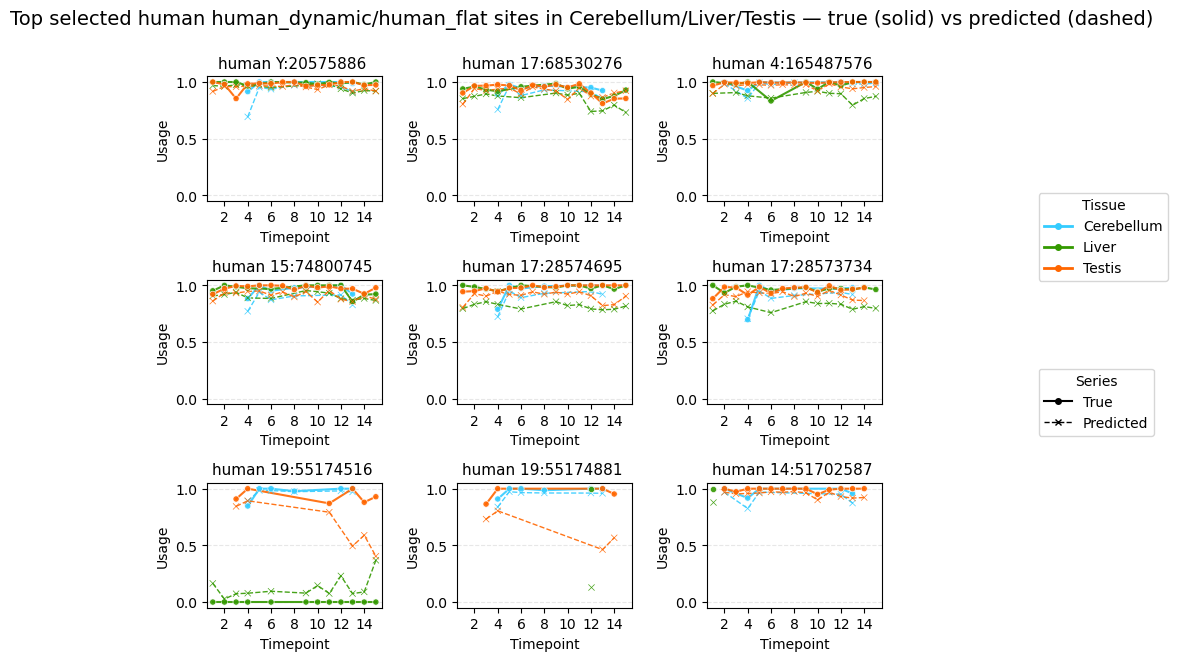

In [8]:
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_predictions, TISSUE_COLORS, TISSUE_ORDER,
)

CONFIRM_TISSUES = ["Cerebellum", "Liver", "Testis"]   # or None for all tissues
CONFIRM_N       = 9                                   # number of top sites to show

def _human_all_tissues(positions):
    """Human predictions (all tissues) at the given positions, for plotting."""
    posset = {int(x) for x in positions}
    ppath = _pred_path("human")
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=[("Position", "in", list(posset))])
        except Exception:
            df = pd.read_parquet(ppath); df = df[df["Position"].isin(posset)]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns:
            df["Species"] = "human"
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df
    npz = _pred_npz("human")
    if not os.path.exists(npz):
        return None
    meta = json.load(open(os.path.join(DATA_DIR, SPECIES_SCI["human"], "usage.json")))
    idx_to_label = {int(v): k for k, v in meta["condition_labels"].items()}
    d = np.load(npz)
    cond = np.asarray(d["cond_ids"], int)
    cp = np.asarray(d["chr_pos"]).astype(str)
    ch = np.array([s.split(":")[0] for s in cp]); po = np.array([int(s.split(":")[1]) for s in cp])
    keep = np.isin(po, list(posset))
    tis = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond])
    tp  = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond])
    return pd.DataFrame({"Species": "human", "Chromosome": ch[keep], "Position": po[keep],
                         "Tissue": tis[keep], "Timepoint": tp[keep],
                         "SSE_true": np.asarray(d["true"], float)[keep],
                         "SSE_pred": np.asarray(d["pred"], float)[keep]})

_lbl = "/".join(DIRECTIONS)
if len(human_sel):
    top_sites = human_sel.sort_values("pred_r", ascending=False).head(CONFIRM_N)["site"].tolist()
    hp = _human_all_tissues([int(s.split(":")[1]) for s in top_sites])
    if hp is None or hp.empty:
        print("No human predictions to plot.")
    else:
        fig = plot_splice_site_predictions(
            hp, site_coords=[f"human {s}" for s in top_sites],
            true_col="SSE_true", pred_col="SSE_pred",
            tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER, tissue_subset=CONFIRM_TISSUES,
            n_cols=min(3, len(top_sites)), split_by_tissue=False,
            title=f"Top selected human {_lbl} sites in {'/'.join(CONFIRM_TISSUES)} "
                  f"— true (solid) vs predicted (dashed)",
        )
        if fig is not None:
            for ax in fig.axes:
                ax.set_ylim(-0.05, 1.05)
            fig.savefig(os.path.join(OUT_DIR, f"selected_human_sites_{FOCUS_TISSUE.lower()}.png"),
                        dpi=200, bbox_inches="tight")
            plt.show()
else:
    print("No selected human sites to confirm.")

## 4 — Other species: trajectory at the orthologous site

For each candidate human site, pull its orthologue in each other species, score the
trajectory in the focus tissue, and correlate it against the human trajectory.

In [9]:
# Candidate human sites and their orthologue positions per species
import bisect

cand_sites = human_sel["site"].tolist()
hu_traj = hu_wide.loc[cand_sites].to_numpy()          # (n_cand, 15) human true trajectory

records = {s: {} for s in cand_sites}
other_wide = {}        # sp -> DataFrame(index=human_site, cols=1..15) true trajectory
other_pred_wide = {}   # sp -> DataFrame(index=human_site, cols=1..15) predicted trajectory

def _nearest(sorted_pos, pos, tol):
    """Nearest value in sorted_pos to pos within +/- tol (or None)."""
    if len(sorted_pos) == 0:
        return None
    j = bisect.bisect_left(sorted_pos, pos)
    cand = [sorted_pos[k] for k in (j - 1, j) if 0 <= k < len(sorted_pos)]
    if not cand:
        return None
    best = min(cand, key=lambda x: abs(x - pos))
    return int(best) if abs(best - pos) <= tol else None

for sp in OTHER_SPECIES:
    m = ortho_map.get(sp)
    if m is None:
        print(f"{sp}: no orthologues"); continue
    m = m[m.index.isin(cand_sites)]
    if m.empty:
        print(f"{sp}: no orthologues for candidates"); continue

    # Load a +/- ORTHO_TOL window around each orthologue so a nearby predicted site is
    # available to snap to (exon-level lift-over is often off by 1-2 bp).
    base = m["pos"].astype(int).unique()
    positions = sorted({int(p) + d for p in base for d in range(-ORTHO_TOL, ORTHO_TOL + 1)})

    st_sp, wide_sp = trajectory_stats(load_focus_usage(sp, FOCUS_TISSUE, positions=positions))
    st_sp = st_sp.set_index("site")

    pred_sp = load_predictions(sp, FOCUS_TISSUE, positions=positions)
    if pred_sp is None:
        pm_sp, pw_sp = None, None
        print(f"{sp}: predictions MISSING — divergence there cannot be validated")
    else:
        pm_sp = pred_site_metrics(pred_sp)
        pred_sp["site"] = pred_sp["Chromosome"].astype(str) + ":" + pred_sp["Position"].astype(str)
        pw_sp = (pred_sp.groupby(["site", "Timepoint"])["pred"].mean()
                        .unstack("Timepoint").reindex(columns=TPS))

    # Positions available to snap to (prefer predicted sites so pred metrics exist;
    # fall back to usage sites when this species has no predictions).
    if pm_sp is not None and len(pred_sp):
        snap_src = pred_sp
    else:
        snap_src = st_sp.reset_index()
    pos_by_chrom = {c: np.sort(np.unique(d["Position"].astype(int).values))
                    for c, d in snap_src.groupby(snap_src["Chromosome"].astype(str))}

    ow  = pd.DataFrame(index=cand_sites, columns=TPS, dtype=float)
    opw = pd.DataFrame(index=cand_sites, columns=TPS, dtype=float)
    n_exact = n_snapped = 0
    for hsite in m.index:
        chrom = str(m.loc[hsite, "chrom"]); pos = int(m.loc[hsite, "pos"])
        snapped = _nearest(pos_by_chrom.get(chrom, np.array([])), pos, ORTHO_TOL)
        if snapped is None:
            continue
        ssite = f"{chrom}:{snapped}"
        if ssite not in st_sp.index:        # need a usage trajectory there
            continue
        n_exact += (snapped == pos); n_snapped += (snapped != pos)
        row = st_sp.loc[ssite]
        hu_i = cand_sites.index(hsite)
        traj_o = wide_sp.loc[ssite].to_numpy()
        ow.loc[hsite] = traj_o
        rec = dict(ortho_site=ssite, n_obs=int(row["n_obs"]),
                   amplitude=float(row["amplitude"]),
                   shape=classify_traj(traj_o),
                   corr=xcorr(hu_traj[hu_i], traj_o),
                   pred_r=np.nan, pred_rmse=np.nan)
        if pm_sp is not None and ssite in pm_sp.index:
            rec["pred_r"]    = float(pm_sp.loc[ssite, "pred_r"])
            rec["pred_rmse"] = float(pm_sp.loc[ssite, "pred_rmse"])
            if pw_sp is not None and ssite in pw_sp.index:
                opw.loc[hsite] = pw_sp.loc[ssite].to_numpy()
        records[hsite][sp] = rec
    other_wide[sp] = ow
    other_pred_wide[sp] = opw
    n_found = sum(sp in records[h] for h in cand_sites)
    n_pred  = sum(sp in records[h] and np.isfinite(records[h][sp]["pred_rmse"]) for h in cand_sites)
    print(f"{sp}: orthologue trajectory for {n_found:,}/{len(cand_sites):,} candidates "
          f"({n_pred:,} with predictions; {n_exact} exact + {n_snapped} snapped <= {ORTHO_TOL}bp)")

mouse: orthologue trajectory for 1,335/6,486 candidates (1,335 with predictions; 609 exact + 726 snapped <= 2bp)
rat: orthologue trajectory for 1,409/6,486 candidates (1,409 with predictions; 544 exact + 865 snapped <= 2bp)
rabbit: orthologue trajectory for 1,984/6,486 candidates (1,984 with predictions; 1185 exact + 799 snapped <= 2bp)
opossum: predictions MISSING — divergence there cannot be validated
opossum: orthologue trajectory for 4,805/6,486 candidates (0 with predictions; 3109 exact + 1696 snapped <= 2bp)


## 5 — Divergence: opposite roles in human vs another species

Each trajectory is given a **role** by `role()` — `dynamic` (up/down shape, amplitude
`>= AMP_DYNAMIC`) or `flat` (flat shape, amplitude `<= AMP_FLAT`). A (human site, species)
pair **diverges** when the two roles are opposite, in either direction requested by
`DIRECTIONS`:

- **human_dynamic** — dynamic in human, flat in the other species
- **human_flat** — flat in human, dynamic in the other species

with an amplitude gap `>= MIN_AMP_GAP` between them. Built in three steps:

1. **All candidates across species** — tabulate/plot every candidate's orthologue per species.
2. **Well-predicted elsewhere** — keep candidates whose orthologue is predicted well in ≥1 species.
3. **Divergent** — of those, keep pairs whose roles are opposite (a real divergence).

### 5.1 — All human candidates across species (no filtering yet)

One row per candidate with its orthologue shape / amplitude / prediction metrics per species,
and — for each candidate — a figure with **one panel per species** (via
`plot_splice_site_predictions`): true (solid) vs predicted (dashed) usage, coloured by tissue.

In [10]:
# Per-(candidate) table with each species' orthologue role / amplitude / prediction quality
rows = []
for hsite in cand_sites:
    hrow = human_sel[human_sel["site"] == hsite].iloc[0]
    human_role, human_shape, human_amp = hrow["human_role"], hrow["shape"], float(hrow["amplitude"])
    rec = records[hsite]
    per_sp = {}
    for sp in OTHER_SPECIES:
        r = rec.get(sp)
        if not r or r["n_obs"] < MIN_TIMEPOINTS or not r.get("shape"):
            continue
        osh, oamp = r["shape"], r["amplitude"]
        orole = role(osh, oamp)
        well = is_well_predicted(r["pred_r"], r["pred_rmse"], true_dynamic=(orole == "dynamic"))
        direction, gap = None, np.nan
        if human_role == "dynamic" and orole == "flat" and (human_amp - oamp) >= MIN_AMP_GAP:
            direction, gap = "human_dynamic->other_flat", human_amp - oamp
        elif human_role == "flat" and orole == "dynamic" and (oamp - human_amp) >= MIN_AMP_GAP:
            direction, gap = "human_flat->other_dynamic", oamp - human_amp
        per_sp[sp] = dict(shape=osh, amp=oamp, role=orole, corr=r["corr"],
                          pred_r=r["pred_r"], pred_rmse=r["pred_rmse"], well=well,
                          direction=direction, div_well=(direction is not None and well), gap=gap)
    div_dirs = sorted({v["direction"] for v in per_sp.values() if v["direction"]})
    out = dict(
        site=hsite, Strand=hrow["Strand"], human_role=human_role, human_shape=human_shape,
        human_amplitude=round(human_amp, 3),
        pred_r=round(float(hrow["pred_r"]), 3), pred_rmse=round(float(hrow["pred_rmse"]), 3),
        n_species=len(per_sp),
        n_well_pred=sum(v["well"] for v in per_sp.values()),
        n_divergent=sum(v["direction"] is not None for v in per_sp.values()),
        n_divergent_well_pred=sum(v["div_well"] for v in per_sp.values()),
        directions=",".join(div_dirs),
        divergent_species=",".join(sp for sp, v in per_sp.items() if v["direction"]),
        divergent_well_pred_species=",".join(sp for sp, v in per_sp.items() if v["div_well"]),
        max_amp_gap=round(max([v["gap"] for v in per_sp.values() if v["div_well"] and np.isfinite(v["gap"])] or [np.nan]), 3),
    )
    for sp in OTHER_SPECIES:
        v = per_sp.get(sp, {})
        out[f"{sp}_shape"]     = v.get("shape")
        out[f"{sp}_amp"]       = round(v["amp"], 3) if "amp" in v else np.nan
        out[f"{sp}_pred_rmse"] = round(v["pred_rmse"], 3) if v.get("pred_rmse") is not None and np.isfinite(v.get("pred_rmse", np.nan)) else np.nan
    rows.append(out)

cand_table = pd.DataFrame(rows)
print(f"{len(cand_table):,} human candidates with an orthologue in >=1 other species")

cand_table_orth = cand_table[cand_table["n_species"]>2].copy() 
print(f"{len(cand_table_orth):,} human candidates with an orthologue in >=3 other species")

display(cand_table_orth.head(20))

6,486 human candidates with an orthologue in >=1 other species
1,001 human candidates with an orthologue in >=3 other species


,site,Strand,human_role,human_shape,human_amplitude,pred_r,pred_rmse,n_species,n_well_pred,n_divergent,...,mouse_pred_rmse,rat_shape,rat_amp,rat_pred_rmse,rabbit_shape,rabbit_amp,rabbit_pred_rmse,opossum_shape,opossum_amp,opossum_pred_rmse
121,1:25749334,+,flat,flat_high,0.072,0.464,0.060,3,1,0,...,NaN,flat_high,0.084,0.381,flat_high,0.073,0.126,flat_high,0.047,NaN
128,1:29202044,-,flat,flat_high,0.066,0.546,0.138,4,3,0,...,0.149,flat_high,0.101,0.104,flat_high,0.062,0.106,flat_high,0.171,NaN
129,1:29206904,-,flat,flat_high,0.067,0.175,0.114,4,3,0,...,0.166,up-down,0.179,0.125,up-down,0.122,0.126,complex,0.159,NaN
130,1:29216004,-,flat,flat_high,0.060,0.554,0.113,4,3,0,...,0.101,up_early,0.308,0.125,up-down,0.211,0.093,flat_high,0.154,NaN
131,1:29216135,-,flat,flat_high,0.071,0.153,0.116,4,3,0,...,0.070,down-up,0.096,0.118,up_late,0.209,0.108,up-down,0.241,NaN
132,1:29216587,-,flat,flat_high,0.046,0.113,0.122,4,3,0,...,0.112,flat_high,0.113,0.101,down-up,0.206,0.138,flat_high,0.215,NaN
208,1:39564541,-,flat,flat_high,0.050,0.558,0.084,3,2,0,...,NaN,down-up,0.098,0.135,flat_high,0.083,0.114,flat_high,0.069,NaN
213,1:39565377,-,flat,flat_high,0.062,0.623,0.054,3,2,0,...,NaN,flat_high,0.033,0.128,flat_high,0.065,0.112,flat_high,0.182,NaN
215,1:39567750,-,flat,flat_high,0.031,0.725,0.058,3,2,0,...,NaN,flat_high,0.135,0.108,flat_high,0.040,0.106,flat_high,0.075,NaN
220,1:39570001,-,flat,flat_high,0.081,0.696,0.086,3,2,0,...,NaN,flat_high,0.065,0.119,flat_high,0.018,0.181,flat_high,0.182,NaN


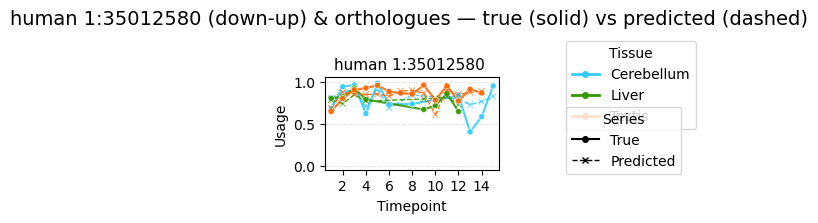

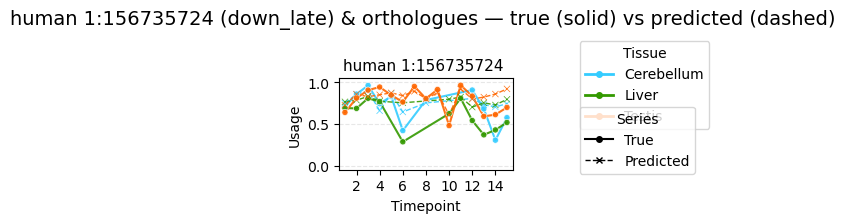

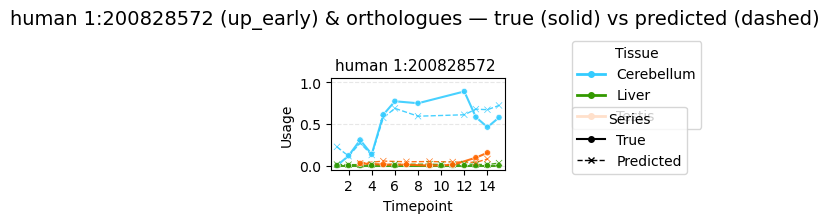

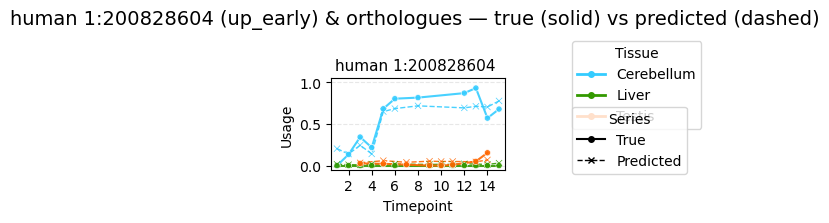

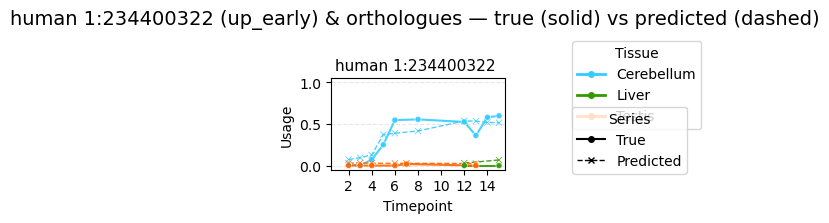

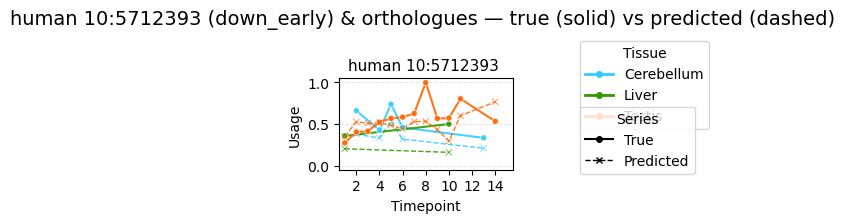

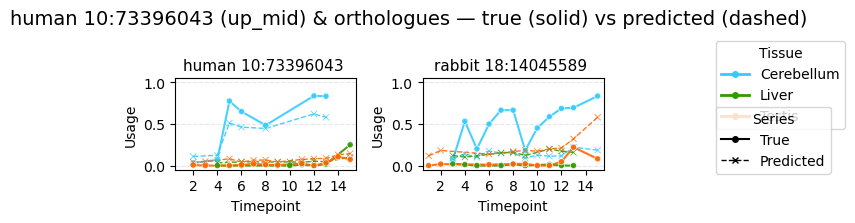

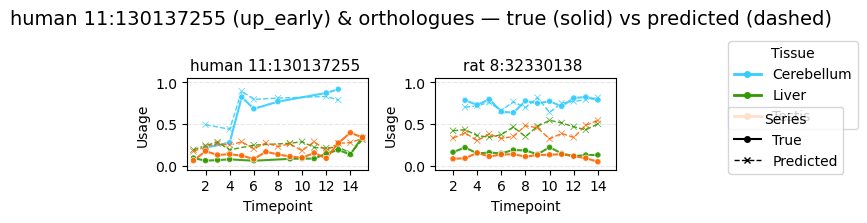

In [11]:
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_predictions, TISSUE_COLORS, TISSUE_ORDER,
)

PLOT_TISSUES        = ["Cerebellum", "Liver", "Testis"]   # or None for all tissues
MAX_PLOT_CANDIDATES = 8                                    # candidates to plot (one figure each)

def _load_pred_all_tissues(sp, positions):
    """Predictions for a species across ALL tissues at given positions (for plotting)."""
    posset = {int(x) for x in positions}
    ppath = _pred_path(sp)
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=[("Position", "in", list(posset))])
        except Exception:
            df = pd.read_parquet(ppath); df = df[df["Position"].isin(posset)]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns:
            df["Species"] = sp
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df
    npz = _pred_npz(sp)
    if not os.path.exists(npz):
        return None
    meta = json.load(open(os.path.join(DATA_DIR, SPECIES_SCI[sp], "usage.json")))
    idx_to_label = {int(v): k for k, v in meta["condition_labels"].items()}
    d = np.load(npz)
    cond = np.asarray(d["cond_ids"], int)
    cp = np.asarray(d["chr_pos"]).astype(str)
    ch = np.array([s.split(":")[0] for s in cp]); po = np.array([int(s.split(":")[1]) for s in cp])
    keep = np.isin(po, list(posset))
    tis = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond])
    tp  = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond])
    return pd.DataFrame({"Species": sp, "Chromosome": ch[keep], "Position": po[keep],
                         "Tissue": tis[keep], "Timepoint": tp[keep],
                         "SSE_true": np.asarray(d["true"], float)[keep],
                         "SSE_pred": np.asarray(d["pred"], float)[keep]})

# One figure per candidate; each species (human + orthologues) is its own panel; only show human sites where shape doesn't have "flat*"".
cand_sites_dyn = human_sel[~human_sel["shape"].str.startswith("flat")]["site"].tolist()
plot_candidates = [h for h in cand_sites_dyn if records[h]]   # only those with >=1 orthologue
for hsite in plot_candidates[:MAX_PLOT_CANDIDATES]:
    coords, frames = [f"human {hsite}"], []
    hf = _load_pred_all_tissues("human", [int(hsite.split(":")[1])])
    if hf is not None and not hf.empty:
        frames.append(hf)
    else:
        coords = []
    for sp in OTHER_SPECIES:
        if sp in records[hsite]:
            ssite = records[hsite][sp]["ortho_site"]
            fr = _load_pred_all_tissues(sp, [int(ssite.split(":")[1])])
            if fr is not None and not fr.empty:
                frames.append(fr)
                coords.append(f"{sp} {ssite}")
    if not frames:
        print(f"{hsite}: no predictions to plot"); continue
    shp = human_sel.set_index("site").loc[hsite, "shape"]
    fig = plot_splice_site_predictions(
        pd.concat(frames, ignore_index=True), site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER, tissue_subset=PLOT_TISSUES,
        n_cols=len(coords), split_by_tissue=False,
        title=f"human {hsite} ({shp}) & orthologues — true (solid) vs predicted (dashed)",
    )
    if fig is not None:
        for ax in fig.axes:
            ax.set_ylim(-0.05, 1.05)
        fig.savefig(os.path.join(OUT_DIR,
                    f"candidate_{hsite.replace(':', '_')}_across_species.png"),
                    dpi=200, bbox_inches="tight")
        plt.show()

### 5.2 — Keep candidates well-predicted in the other species

Require the orthologue to be predicted correctly in ≥1 other species (`n_well_pred >= 1`),
independent of whether it diverges.

In [12]:
well_pred = (cand_table[cand_table["n_well_pred"] >= 1]
             .sort_values("pred_r", ascending=False).reset_index(drop=True))
print(f"{len(well_pred):,} / {len(cand_table):,} candidates have an orthologue that is "
      f"well predicted in >=1 other species")
display(well_pred.head(20))

2,971 / 6,486 candidates have an orthologue that is well predicted in >=1 other species


,site,Strand,human_role,human_shape,human_amplitude,pred_r,pred_rmse,n_species,n_well_pred,n_divergent,...,mouse_pred_rmse,rat_shape,rat_amp,rat_pred_rmse,rabbit_shape,rabbit_amp,rabbit_pred_rmse,opossum_shape,opossum_amp,opossum_pred_rmse
0,17:68530276,+,flat,flat_high,0.046,0.993,0.071,2,1,0,...,NaN,None,NaN,NaN,flat_high,0.099,0.065,flat_high,0.021,NaN
1,17:28573734,-,flat,flat_high,0.070,0.990,0.050,2,1,0,...,NaN,None,NaN,NaN,flat_high,0.048,0.041,flat_high,0.019,NaN
2,17:28574695,-,flat,flat_high,0.058,0.990,0.065,2,1,0,...,NaN,None,NaN,NaN,flat_high,0.057,0.094,flat_high,0.010,NaN
3,14:51702587,+,flat,flat_high,0.083,0.986,0.063,2,1,0,...,NaN,flat_high,0.101,0.115,None,NaN,NaN,flat_high,0.083,NaN
4,15:40737287,-,flat,flat_high,0.021,0.982,0.095,2,1,0,...,NaN,flat_high,0.175,0.083,None,NaN,NaN,flat_high,0.042,NaN
5,15:62675216,+,flat,flat_high,0.042,0.982,0.104,4,3,0,...,0.122,flat_high,0.062,0.078,flat_high,0.031,0.072,flat_high,0.072,NaN
6,8:130124012,-,flat,flat_high,0.040,0.980,0.053,2,1,0,...,NaN,None,NaN,NaN,down-up,0.217,0.087,down-up,0.141,NaN
7,X:108091406,-,flat,flat_high,0.037,0.978,0.087,2,1,0,...,NaN,None,NaN,NaN,complex,0.153,0.089,flat_high,0.073,NaN
8,17:28575420,-,flat,flat_high,0.052,0.977,0.103,2,1,1,...,NaN,None,NaN,NaN,flat_high,0.021,0.073,up_late,0.499,NaN
9,11:644653,-,flat,flat_high,0.049,0.977,0.018,1,1,0,...,0.067,None,NaN,NaN,None,NaN,NaN,None,NaN,NaN


### 5.3 — Keep the divergent ones (opposite roles)

Of the well-predicted candidates, keep those with a species where the orthologue's role is
**opposite** to human (`n_divergent_well_pred >= 1`) — dynamic↔flat in either direction —
ranked by human prediction quality then divergence size.

In [13]:
result = (well_pred[well_pred["n_divergent_well_pred"] >= 1]
          .sort_values(["pred_r", "max_amp_gap"], ascending=[False, False])
          .reset_index(drop=True))

out_csv = os.path.join(OUT_DIR, f"cross_species_divergence_{FOCUS_TISSUE.lower()}.csv")
result.to_csv(out_csv, index=False)
print(f"{len(result):,} sites with opposite roles (and correctly predicted) in >=1 other species")
if len(result):
    print("Directions:", result["directions"].value_counts().to_dict())
    print("Human role:", result["human_role"].value_counts().to_dict())
print(f"Saved -> {out_csv}")
result.head(20)

5 sites with opposite roles (and correctly predicted) in >=1 other species
Directions: {'human_flat->other_dynamic': 3, 'human_dynamic->other_flat': 2}
Human role: {'flat': 3, 'dynamic': 2}
Saved -> /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/cross_species_divergence/cross_species_divergence_cerebellum.csv


,site,Strand,human_role,human_shape,human_amplitude,pred_r,pred_rmse,n_species,n_well_pred,n_divergent,...,mouse_pred_rmse,rat_shape,rat_amp,rat_pred_rmse,rabbit_shape,rabbit_amp,rabbit_pred_rmse,opossum_shape,opossum_amp,opossum_pred_rmse
0,5:146144471,-,dynamic,down_late,0.474,0.778,0.095,3,1,2,...,NaN,flat_high,0.172,0.204,flat_high,0.024,0.108,flat_high,0.075,NaN
1,2:32377768,+,dynamic,down_late,0.500,0.709,0.103,2,1,1,...,NaN,None,NaN,NaN,flat_high,0.042,0.064,up-down,0.134,NaN
2,20:34480598,+,flat,flat_high,0.065,0.699,0.080,3,2,1,...,0.136,None,NaN,NaN,flat_high,0.023,0.105,flat_high,0.118,NaN
3,17:3033391,+,flat,flat_high,0.080,0.488,0.106,1,1,1,...,NaN,None,NaN,NaN,down_late,0.448,0.158,None,NaN,NaN
4,10:116676501,-,flat,flat_high,0.060,0.333,0.082,2,1,1,...,NaN,down-up,0.502,0.106,None,NaN,NaN,flat_high,0.102,NaN


## 6 — Example trajectories

For the top sites, plot usage across tissues with the shared `plot_splice_site_dynamics`,
coloured by the predefined `TISSUE_COLORS`. **True and predicted are drawn as separate
figures** (one per metric), each showing the human site next to its orthologue in the
species where the trajectory diverges *and* is correctly predicted.

Set `TISSUE_SUBSET` to restrict to a few tissues (default: Cerebellum, Testis, Liver);
set it to `None` to show all tissues.

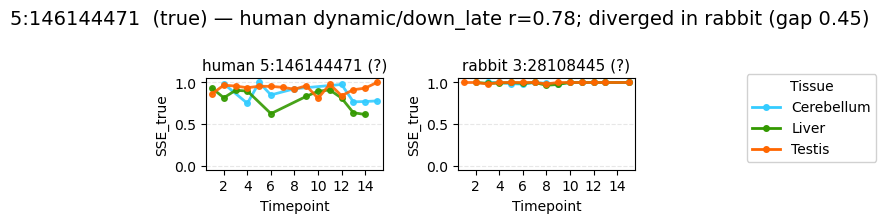

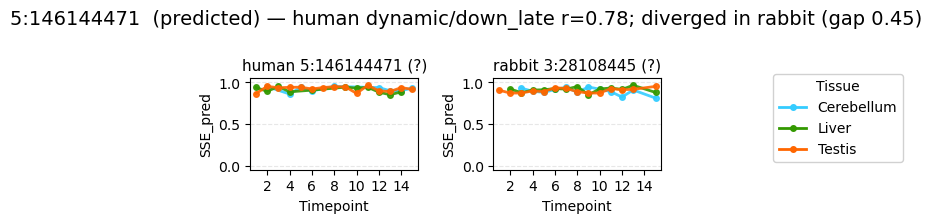

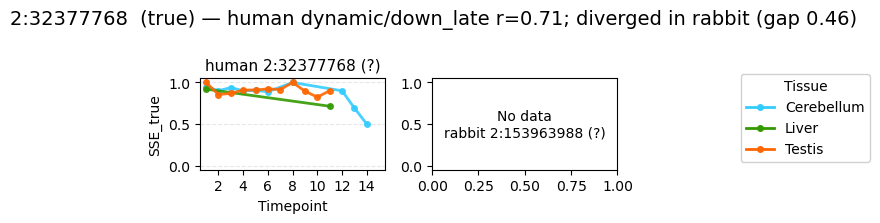

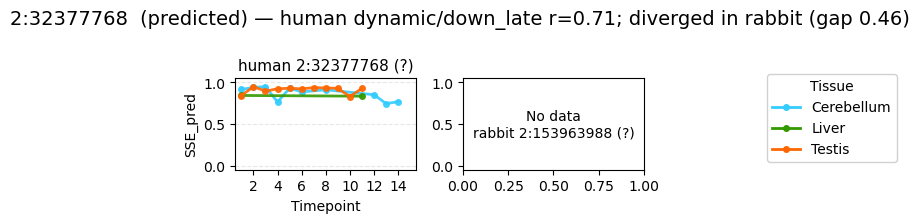

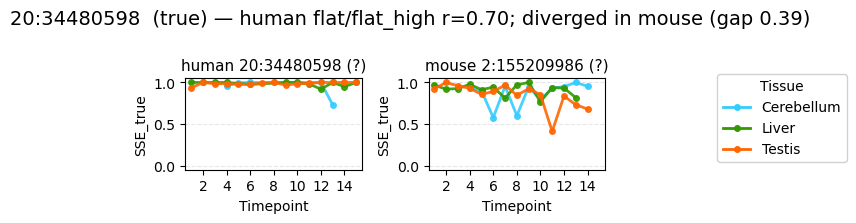

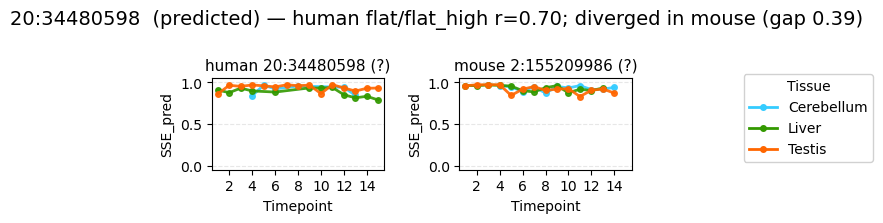

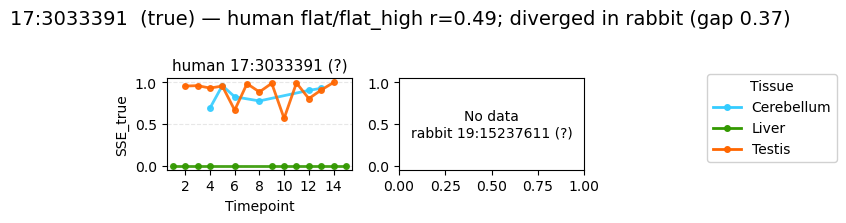

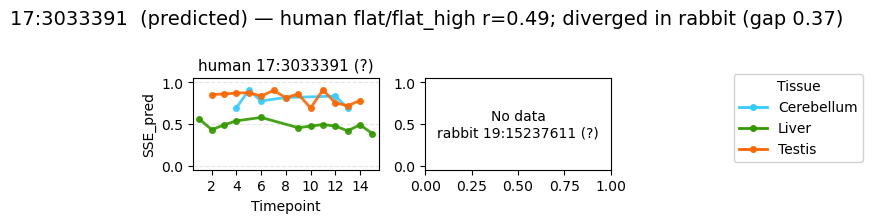

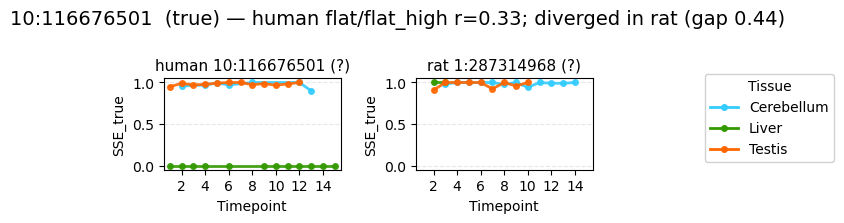

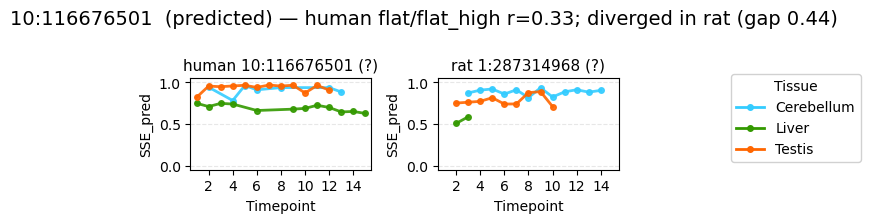

In [14]:
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_dynamics, TISSUE_COLORS, TISSUE_ORDER,
)

N_PLOT = 5   # number of top human sites to plot
TISSUE_SUBSET = ["Cerebellum", "Testis", "Liver"]   # or None for all tissues

def load_pred_for_plot(sp, positions):
    """Predictions for a species across ALL tissues at the given positions, in the
    column layout the plotting helpers expect (Species / Chromosome / Position /
    Tissue / Timepoint / SSE_true / SSE_pred)."""
    posset = {int(x) for x in positions}
    ppath = _pred_path(sp)
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=[("Position", "in", list(posset))])
        except Exception:
            df = pd.read_parquet(ppath)
            df = df[df["Position"].isin(posset)]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns:
            df["Species"] = sp
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df

    npz = _pred_npz(sp)
    if not os.path.exists(npz):
        return None
    meta = json.load(open(os.path.join(DATA_DIR, SPECIES_SCI[sp], "usage.json")))
    idx_to_label = {int(v): k for k, v in meta["condition_labels"].items()}
    d = np.load(npz)
    cond = np.asarray(d["cond_ids"], int)
    cp = np.asarray(d["chr_pos"]).astype(str)
    chrom = np.array([s.split(":")[0] for s in cp])
    pos   = np.array([int(s.split(":")[1]) for s in cp])
    keep = np.isin(pos, list(posset))
    tis = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond])
    tp  = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond])
    return pd.DataFrame({"Species": sp, "Chromosome": chrom[keep], "Position": pos[keep],
                         "Tissue": tis[keep], "Timepoint": tp[keep],
                         "SSE_true": np.asarray(d["true"], float)[keep],
                         "SSE_pred": np.asarray(d["pred"], float)[keep]})

top = result.head(N_PLOT)

# Combined predictions (all tissues) for the sites to plot: human + their orthologues
frames = []
hf = load_pred_for_plot("human", [int(s.split(":")[1]) for s in top["site"]])
if hf is not None:
    frames.append(hf)
for sp in OTHER_SPECIES:
    m = ortho_map.get(sp)
    if m is None:
        continue
    pos_sp = m[m.index.isin(top["site"])]["pos"].unique()
    if len(pos_sp):
        f = load_pred_for_plot(sp, pos_sp)
        if f is not None:
            frames.append(f)
plot_preds = pd.concat(frames, ignore_index=True) if frames else None

if plot_preds is None or top.empty:
    print("No predictions available to plot (or no diverged sites).")
else:
    for _, r in top.iterrows():
        hsite = r["site"]
        coords = [f"human {hsite}"]
        for sp in filter(None, str(r["divergent_well_pred_species"]).split(",")):
            m = ortho_map.get(sp)
            if m is not None and hsite in m.index:
                coords.append(f"{sp} {m.loc[hsite, 'chrom']}:{int(m.loc[hsite, 'pos'])}")

        # True and predicted usage as SEPARATE figures (same tissue colours)
        for metric, label in [("SSE_true", "true"), ("SSE_pred", "predicted")]:
            fig = plot_splice_site_dynamics(
                plot_preds, site_coords=coords, metric=metric,
                tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER,
                tissue_subset=TISSUE_SUBSET, n_cols=len(coords),
                title=(f"{hsite}  ({label}) — human {r['human_role']}/{r['human_shape']} "
                       f"r={r['pred_r']:.2f}; diverged in {r['divergent_well_pred_species']} "
                       f"(gap {r['max_amp_gap']:.2f})"),
            )
            if fig is not None:
                for ax in fig.axes:
                    ax.set_ylim(-0.05, 1.05)   # SSE is always on a 0-1 scale
                fig.savefig(os.path.join(
                    OUT_DIR, f"diverged_{hsite.replace(':', '_')}_{label}.png"),
                    dpi=200, bbox_inches="tight")
                plt.show()

## 7 — Gene-level orthology

Per-site orthology (§1) maps a single exon position, which can be unreliable. Here we go by
**gene** instead: find the gene the human site sits in, map it to its **orthologous genes**
via the gene orthogroups, and plot **all** splice sites in each orthologous gene (as a genomic
range). This shows the whole gene's splicing landscape in every species, coloured by tissue.

Gene coordinates come from the per-species parquet annotation
(`<Species_sci>/gene_annotation.parquet`, `Feature == "gene"`); genes are linked across
species by the gene orthogroups.

In [15]:
# Gene coordinates from the parquet gene annotations (one file per species), replacing
# the slow GTF parse. gene_annotation.parquet is the GTF as a table; we take the gene rows.
GENE_ANNOT_TMPL = os.path.join(DATA_DIR, "{sci}", "gene_annotation.parquet")
ORTHOGROUPS_TSV = "/home/elek/sds/sd17d003/Anamaria/folds_splits/data/orthogroups.tsv"

def load_gene_coords(sp):
    """Gene-level coordinates (Gene / Chromosome / Start / End) for one species."""
    path = GENE_ANNOT_TMPL.format(sci=SPECIES_SCI[sp])
    cols = ["Chromosome", "Feature", "Start", "End", "Strand", "gene_id"]
    try:
        g = pd.read_parquet(path, columns=cols, filters=[("Feature", "==", "gene")])
    except Exception:
        g = pd.read_parquet(path, columns=cols)
        g = g[g["Feature"] == "gene"]
    g = g.rename(columns={"gene_id": "Gene"})
    g["Chromosome"] = g["Chromosome"].astype(str)
    g["Gene"] = g["Gene"].astype(str).str.split(".").str[0]   # strip version suffix
    return (g[["Gene", "Chromosome", "Start", "End", "Strand"]]
            .drop_duplicates("Gene").reset_index(drop=True))

# Load gene coords once, only for the species we plot.
GENE_SPECIES = ["human"] + OTHER_SPECIES
gene_coords = {}
for sp in GENE_SPECIES:
    path = GENE_ANNOT_TMPL.format(sci=SPECIES_SCI[sp])
    if os.path.exists(path):
        gene_coords[sp] = load_gene_coords(sp)
        print(f"{sp}: {len(gene_coords[sp]):,} genes")
    else:
        print(f"{sp}: {path} missing — skipped")

# Tidy gene orthogroups: one row per (orthogroup_id, Gene, Species)
_og = pd.read_csv(ORTHOGROUPS_TSV, sep="\t")
orthogroups = (_og.assign(genes=_og["genes"].str.split(";"))
                  .explode("genes").rename(columns={"genes": "Gene"}).reset_index(drop=True))
_prefix = [("ENSMUSG", "mouse"), ("ENSRNOG", "rat"), ("ENSOCUG", "rabbit"),
           ("ENSMODG", "opossum"), ("ENSMMUG", "macaque"), ("ENSGALG", "chicken"),
           ("ENSG", "human")]
def _infer_species(g):
    for pre, sp in _prefix:
        if g.startswith(pre):
            return sp
    return None
orthogroups["Species"] = orthogroups["Gene"].map(_infer_species)
print(f"orthogroups: {orthogroups['orthogroup_id'].nunique():,} groups, {len(orthogroups):,} genes")

human: 78,899 genes
mouse: 47,729 genes
rat: 26,689 genes
rabbit: 23,669 genes
opossum: 23,899 genes
orthogroups: 23,016 groups, 147,419 genes


In [16]:
def genes_at(sp, chrom, pos):
    """Ensembl gene IDs whose span contains a position in a species."""
    gc = gene_coords.get(sp)
    if gc is None:
        return []
    hit = gc[(gc["Chromosome"] == str(chrom)) & (gc["Start"] <= pos) & (gc["End"] >= pos)]
    return hit["Gene"].tolist()

def ortholog_genes(human_gene):
    """{species: [gene coords rows]} for the orthologues of a human gene."""
    ogs = orthogroups.loc[orthogroups["Gene"] == human_gene, "orthogroup_id"].unique()
    members = orthogroups[orthogroups["orthogroup_id"].isin(ogs)]
    out = {}
    for sp in GENE_SPECIES:
        gids = members.loc[members["Species"] == sp, "Gene"].tolist()
        gc = gene_coords.get(sp)
        if gc is None or not gids:
            continue
        rows = gc[gc["Gene"].isin(gids)]
        if len(rows):
            out[sp] = rows
    return out

def load_pred_region(sp, chrom, start, end):
    """All predictions for a species in a genomic window (all tissues)."""
    filt = [("Chromosome", "==", str(chrom)),
            ("Position", ">=", int(start)), ("Position", "<=", int(end))]
    ppath = _pred_path(sp)
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=filt)
        except Exception:
            df = pd.read_parquet(ppath)
            df = df[(df["Chromosome"].astype(str) == str(chrom)) &
                    (df["Position"].between(int(start), int(end)))]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns:
            df["Species"] = sp
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df
    npz = _pred_npz(sp)
    if not os.path.exists(npz):
        return None
    meta = json.load(open(os.path.join(DATA_DIR, SPECIES_SCI[sp], "usage.json")))
    idx_to_label = {int(v): k for k, v in meta["condition_labels"].items()}
    d = np.load(npz)
    cond = np.asarray(d["cond_ids"], int)
    cp = np.asarray(d["chr_pos"]).astype(str)
    ch = np.array([s.split(":")[0] for s in cp])
    po = np.array([int(s.split(":")[1]) for s in cp])
    keep = (ch == str(chrom)) & (po >= int(start)) & (po <= int(end))
    tis = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond])
    tp  = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond])
    return pd.DataFrame({"Species": sp, "Chromosome": ch[keep], "Position": po[keep],
                         "Tissue": tis[keep], "Timepoint": tp[keep],
                         "SSE_true": np.asarray(d["true"], float)[keep],
                         "SSE_pred": np.asarray(d["pred"], float)[keep]})

def inspect_gene_across_species(human_site, tissues=None, metric="both", n_cols=8):
    """Plot all splice sites of the human site's gene and its orthologous genes."""
    chrom, pos = human_site.split(":")[0], int(human_site.split(":")[1])
    hgenes = genes_at("human", chrom, pos)
    if not hgenes:
        print(f"No human gene overlaps {human_site}"); return
    print(f"Human gene(s) at {human_site}: {hgenes}")

    figs = []
    for hg in hgenes:
        og = ortholog_genes(hg)
        if not og:
            print(f"{hg}: no orthologous genes"); continue
        coords, frames = [], []
        for sp, rows in og.items():
            for _, gr in rows.iterrows():
                df = load_pred_region(sp, gr["Chromosome"], gr["Start"], gr["End"])
                if df is not None and not df.empty:
                    # predictions carry no strand; use the gene's strand so the
                    # plotting helpers always have a Strand column
                    df["Strand"] = gr.get("Strand", "?")
                    frames.append(df)
                    coords.append(f"{sp} {gr['Chromosome']}:{int(gr['Start'])}-{int(gr['End'])}")
                    print(f"  {sp} {gr['Gene']} {gr['Chromosome']}:{gr['Start']}-{gr['End']} "
                          f"-> {df[['Chromosome','Position']].drop_duplicates().shape[0]} sites")
        if not frames:
            print(f"{hg}: no predictions in orthologous genes"); continue
        preds = pd.concat(frames, ignore_index=True)
        for col, ttl in ([("SSE_true", "true"), ("SSE_pred", "predicted")]
                         if metric == "both" else [({"true": "SSE_true", "pred": "SSE_pred"}[metric], metric)]):
            fig = plot_splice_site_dynamics(
                preds, site_coords=coords, metric=col,
                tissue_colors=TISSUE_COLORS, tissue_order=TISSUE_ORDER, tissue_subset=tissues,
                n_cols=n_cols, title=f"{hg} orthologues — {ttl} usage",
            )
            if fig is not None:
                for ax in fig.axes:
                    ax.set_ylim(-0.05, 1.05)
                fig.savefig(os.path.join(OUT_DIR, f"gene_{hg}_{ttl}.png"),
                            dpi=200, bbox_inches="tight")
                figs.append(fig)
        plt.show()
    return figs

In [17]:
SITE = "8:130160784"
_ = inspect_gene_across_species(SITE, tissues=SITE_TISSUES)

NameError: name 'SITE_TISSUES' is not defined

## 8 — Plot sites directly

Plot true (solid) vs predicted (dashed) usage for one site in one species, coloured by tissue.
No ortholog mapping — just give the species and `chrom:pos`.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_predictions, TISSUE_COLORS, TISSUE_ORDER,
)

def load_site_usage(species, chrom, start, end=None):
    """True + predicted usage (all tissues) for a species at a position or range."""
    end = start if end is None else end
    filt = [("Chromosome", "==", str(chrom)),
            ("Position", ">=", int(start)), ("Position", "<=", int(end))]
    ppath = _pred_path(species)
    if os.path.exists(ppath):
        try:
            df = pd.read_parquet(ppath, filters=filt)
        except Exception:
            df = pd.read_parquet(ppath)
            df = df[(df["Chromosome"].astype(str) == str(chrom)) &
                    (df["Position"].between(int(start), int(end)))]
        df = df.rename(columns={"true": "SSE_true", "pred": "SSE_pred"})
        if "Species" not in df.columns:
            df["Species"] = species
        df["Chromosome"] = df["Chromosome"].astype(str)
        return df
    npz = _pred_npz(species)
    if not os.path.exists(npz):
        return None
    meta = json.load(open(os.path.join(DATA_DIR, SPECIES_SCI[species], "usage.json")))
    idx_to_label = {int(v): k for k, v in meta["condition_labels"].items()}
    d = np.load(npz)
    cond = np.asarray(d["cond_ids"], int)
    cp = np.asarray(d["chr_pos"]).astype(str)
    ch = np.array([s.split(":")[0] for s in cp])
    po = np.array([int(s.split(":")[1]) for s in cp])
    keep = (ch == str(chrom)) & (po >= int(start)) & (po <= int(end))
    tis = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond])
    tp  = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond])
    return pd.DataFrame({"Species": species, "Chromosome": ch[keep], "Position": po[keep],
                         "Tissue": tis[keep], "Timepoint": tp[keep],
                         "SSE_true": np.asarray(d["true"], float)[keep],
                         "SSE_pred": np.asarray(d["pred"], float)[keep]})



In [ ]:
def plot_site_usage(species, site, tissues=None, split_by_tissue=False, font_size=14):
    """True (solid) vs predicted (dashed) usage for one or more (species, site) pairs,
    one panel per pair. `species`/`site` may be single strings or parallel lists."""
    species = [species] if isinstance(species, str) else list(species)
    site    = [site]    if isinstance(site, str)    else list(site)
    if len(species) != len(site):
        raise ValueError("species and site must have the same length")

    coords, frames, valid_species = [], [], []
    for sp, s in zip(species, site):
        chrom, pos = s.split(":")[0], int(s.split(":")[1])
        df = load_site_usage(sp, chrom, pos)
        if df is None or df.empty:
            print(f"Warning: No predictions found for species '{sp}' at position '{s}'")
            continue
        
        coord_id = f"{sp} {chrom}:{pos}"
        df["site_coord"] = coord_id
        
        frames.append(df)
        coords.append(coord_id)
        valid_species.append(sp)

    if not frames:
        print("Nothing to plot.")
        return None

    combined_df = pd.concat(frames, ignore_index=True)

    # Filter for tissues before renaming (so 'Brain' data is filtered & loaded properly)
    if tissues is not None:
        combined_df = combined_df[combined_df["Tissue"].isin(tissues)].copy()

    # Map colors for Cerebellum if mapped from Brain
    custom_colors = TISSUE_COLORS.copy() if isinstance(TISSUE_COLORS, dict) else {}
    if "Brain" in custom_colors and "Cerebellum" not in custom_colors:
        custom_colors["Cerebellum"] = custom_colors["Brain"]

    # Annotate 'Brain' as 'Cerebellum' in the DataFrame for figure rendering
    combined_df["Tissue"] = combined_df["Tissue"].replace({"Brain": "Cerebellum"})
    plot_tissues = ["Cerebellum" if t == "Brain" else t for t in tissues] if tissues else None

    fig = plot_splice_site_predictions(
        combined_df, site_coords=coords,
        true_col="SSE_true", pred_col="SSE_pred",
        tissue_colors=custom_colors, tissue_order=TISSUE_ORDER, tissue_subset=plot_tissues,
        n_cols=len(coords), split_by_tissue=split_by_tissue,
        title="",
    )

    if fig is not None:
        plot_axes = [
            ax for ax in fig.axes 
            if ax.get_visible() and getattr(ax, "get_subplotspec", lambda: None)() is not None
        ]

        # Strip default legends
        fig.legends = []
        for ax in fig.axes:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        # Format plot axes with unified font size
        for i, ax in enumerate(plot_axes):
            ax.set_ylim(-0.05, 1.05)
            
            # Species names as panel titles ("human", "rat")
            if i < len(valid_species):
                ax.set_title(valid_species[i].capitalize(), fontsize=font_size)

            ax.set_xlabel("Development", fontsize=font_size)
            ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
            ax.tick_params(axis="both", which="both", labelsize=font_size)
            ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False)

        # Hide y-axis on 2nd subplot
        if len(plot_axes) > 1:
            plot_axes[1].set_ylabel("")
            plot_axes[1].tick_params(axis="y", labelleft=False)

        # 1. Row 1: Line type handles (True vs Pred)
        line_handles = [
            Line2D([0], [0], color="black", linestyle="-", label="True"),
            Line2D([0], [0], color="black", linestyle="--", label="Pred")
        ]

        # 2. Row 2: Tissue color handles
        active_tissues = plot_tissues if plot_tissues else combined_df["Tissue"].unique()
        tissue_handles = [
            Patch(facecolor=custom_colors.get(t, "grey"), edgecolor="none", label=t)
            for t in active_tissues
        ]

        fig.subplots_adjust(wspace=0.08, bottom=0.25)

        # Position Row 1 legend
        leg1 = fig.legend(
            handles=line_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.11),
            ncol=len(line_handles),
            frameon=False,
            fontsize=font_size
        )

        # Position Row 2 legend
        fig.legend(
            handles=tissue_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.03),
            ncol=len(tissue_handles),
            frameon=False,
            fontsize=font_size
        )
        
        # Ensure first legend isn't overwritten
        fig.artists.append(leg1)

    return fig

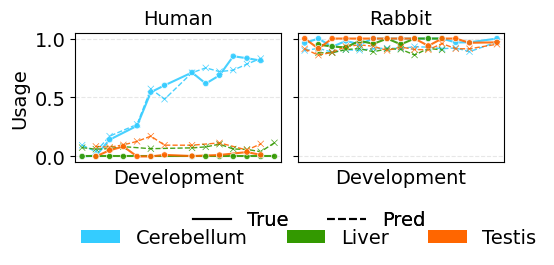

In [ ]:
PLOT_SPECIES = ["human", "rabbit"]
PLOT_SITE    = ["8:130160784", "3:145958829"] # This splice site only alignable to human and rabbit
PLOT_TISSUES = ["Brain", "Liver", "Testis"]

fig = plot_site_usage(PLOT_SPECIES, PLOT_SITE, tissues=PLOT_TISSUES)
if fig is not None:
    _sp = [PLOT_SPECIES] if isinstance(PLOT_SPECIES, str) else PLOT_SPECIES
    _si = [PLOT_SITE]    if isinstance(PLOT_SITE, str)    else PLOT_SITE
    tag = "_".join(f"{sp}_{s}" for sp, s in zip(_sp, _si)).replace(":", "-")
    
    # Save as vectorized PDF
    fig.savefig(
        f"splicing_trajectory_{tag}.pdf", 
        format="pdf", 
        bbox_inches="tight"
    )
    plt.show()

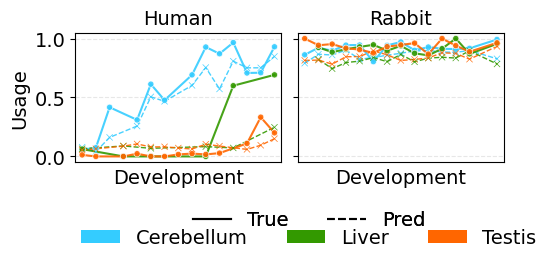

In [ ]:
PLOT_SPECIES = ["human", "rabbit"]
PLOT_SITE    = ["12:50132961", "4:34289757"] # Based on orthology, no alignment
PLOT_TISSUES = ["Brain", "Liver", "Testis"]

fig = plot_site_usage(PLOT_SPECIES, PLOT_SITE, tissues=PLOT_TISSUES)
if fig is not None:
    _sp = [PLOT_SPECIES] if isinstance(PLOT_SPECIES, str) else PLOT_SPECIES
    _si = [PLOT_SITE]    if isinstance(PLOT_SITE, str)    else PLOT_SITE
    tag = "_".join(f"{sp}_{s}" for sp, s in zip(_sp, _si)).replace(":", "-")
    
    # Save as vectorized PDF
    fig.savefig(
        f"splicing_trajectory_{tag}.pdf", 
        format="pdf", 
        bbox_inches="tight"
    )
    plt.show()